# Praktikum 1 Data Mining RKA (N)

**Nama:** Muhamad Nafi Mulyo

**NRP:** 5054251005

Template Kaggle Competition Praktikum Data Mining RKA.

## Setup

In [91]:
# Import Library
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

## Load Data

In [93]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

if "id" not in df_test.columns:
    df_test = df_test.reset_index().rename(columns={"index": "id"})

if "price_class" not in df_train.columns:
    if "price" in df_train.columns:
        df_train["price_class"] = pd.qcut(df_train["price"], q=3, labels=False)
    else:
        raise ValueError("train.csv missing 'price_class' and no 'price' column to derive it from.")

print(df_train.info())
print(df_train.describe())
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 8205 entries, 0 to 8204
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8205 non-null   int64  
 1   model_year                    8205 non-null   int64  
 2   maker                         8205 non-null   str    
 3   model_family                  8205 non-null   str    
 4   trim                          8112 non-null   str    
 5   listing_city                  8205 non-null   str    
 6   listing_state                 8205 non-null   str    
 7   odometer_reading              8205 non-null   int64  
 8   body_color                    7980 non-null   str    
 9   cabin_color                   8000 non-null   str    
 10  city_mpg                      7681 non-null   float64
 11  highway_mpg                   7672 non-null   float64
 12  engine_spec                   8125 non-null   str    
 13  gearbox       

,id,model_year,maker,model_family,trim,listing_city,listing_state,odometer_reading,body_color,cabin_color,...,equipment_count,has_navigation,has_backup_camera,has_bluetooth,has_heated_seats,accident_count,owner_count,commercial_use_flag,clean_title_flag,price_class
0,749,2017,Ford,Fusion,SE FWD,Charlotte,NC,18269,Ingot Silver,Ebony,...,3,0,1,1,0,0,1,0,1,1
1,5410,2016,Ford,F-150,XLT SuperCrew 5.5' Box 4WD,Reading,PA,26195,Shadow Black,Black,...,7,1,1,1,1,0,1,0,1,2
2,2758,2019,Dodge,Journey,GT AWD,Bastrop,LA,34479,Billet Clearcoat,Black/Red,...,5,0,1,1,1,0,0,0,1,2
3,7088,2017,BMW,X3,xDrive28i AWD,Harriman,NY,34083,Jet Black,Black,...,0,0,0,0,0,0,1,0,1,2
4,6319,2015,Volkswagen,e-Golf,SEL Premium,San Diego,CA,25034,Pure White,Titan Black,...,5,1,1,1,1,0,2,0,1,1


## Exploratory Data Analysis

In [94]:
missing_summary = (
    df_train.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_train) * 100).round(2)
missing_summary["dtype"] = missing_summary["feature"].map(df_train.dtypes.astype(str))
missing_summary = missing_summary.sort_values(["missing_count", "missing_pct"], ascending=False).reset_index(drop=True)

display(missing_summary)

print(f"missing a lott: {missing_summary.loc[missing_summary['missing_count'] > 0, 'feature'].head(5).tolist()}")

high_missing = missing_summary[missing_summary["missing_pct"] > 10].copy()
mid_missing = missing_summary[(missing_summary["missing_pct"] > 1) & (missing_summary["missing_pct"] <= 10)].copy()
low_missing = missing_summary[missing_summary["missing_pct"] <= 1].copy()

print("\nmissing > 10%:")
if high_missing.empty:
    print("gaada missing > 10%")
else:
    display(high_missing[["feature", "missing_count", "missing_pct", "dtype"]])

print("\nmissing 1% - 10%:")
if mid_missing.empty:
    print("gaada missing 1% - 10%")
else:
    display(mid_missing[["feature", "missing_count", "missing_pct", "dtype"]])

print("\nmissing <= 1%:")
if low_missing.empty:
    print("gaada missing <= 1%")
else:
    display(low_missing[["feature", "missing_count", "missing_pct", "dtype"]])

,feature,missing_count,missing_pct,dtype
0,combined_mpg,658,8.02,float64
1,mpg_spread,658,8.02,float64
2,highway_mpg,533,6.50,float64
3,city_mpg,524,6.39,float64
4,body_color,225,2.74,str
5,cabin_color,205,2.50,str
6,cylinder_count,190,2.32,float64
7,engine_displacement_l,175,2.13,float64
8,trim,93,1.13,str
9,engine_spec,80,0.98,str


missing a lott: ['combined_mpg', 'mpg_spread', 'highway_mpg', 'city_mpg', 'body_color']

missing > 10%:
gaada missing > 10%

missing 1% - 10%:


,feature,missing_count,missing_pct,dtype
0,combined_mpg,658,8.02,float64
1,mpg_spread,658,8.02,float64
2,highway_mpg,533,6.50,float64
3,city_mpg,524,6.39,float64
4,body_color,225,2.74,str
5,cabin_color,205,2.50,str
6,cylinder_count,190,2.32,float64
7,engine_displacement_l,175,2.13,float64
8,trim,93,1.13,str



missing <= 1%:


,feature,missing_count,missing_pct,dtype
9,engine_spec,80,0.98,str
10,turbo_flag,80,0.98,float64
11,id,0,0.00,int64
12,model_year,0,0.00,int64
13,maker,0,0.00,str
14,model_family,0,0.00,str
15,listing_city,0,0.00,str
16,listing_state,0,0.00,str
17,odometer_reading,0,0.00,int64
18,gearbox,0,0.00,str


In [95]:
# Block Pemisahan Fitur (Perbaikan)
target_col = "price_class"

# Mengambil kolom numerik
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in [target_col, "id"]]

# Mengambil kolom kategorikal (string/object)
cat_cols = df_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['model_year', 'odometer_reading', 'city_mpg', 'highway_mpg', 'model_year_gap_2020', 'odometer_per_model_year_2021', 'combined_mpg', 'mpg_spread', 'engine_displacement_l', 'cylinder_count', 'turbo_flag', 'equipment_count', 'has_navigation', 'has_backup_camera', 'has_bluetooth', 'has_heated_seats', 'accident_count', 'owner_count', 'commercial_use_flag', 'clean_title_flag']
Categorical columns: ['maker', 'model_family', 'trim', 'listing_city', 'listing_state', 'body_color', 'cabin_color', 'engine_spec', 'gearbox', 'drive_layout', 'energy_source']


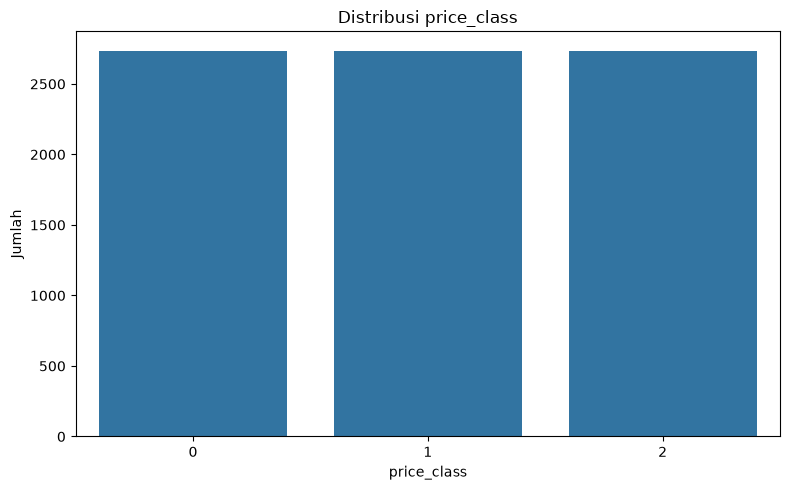

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


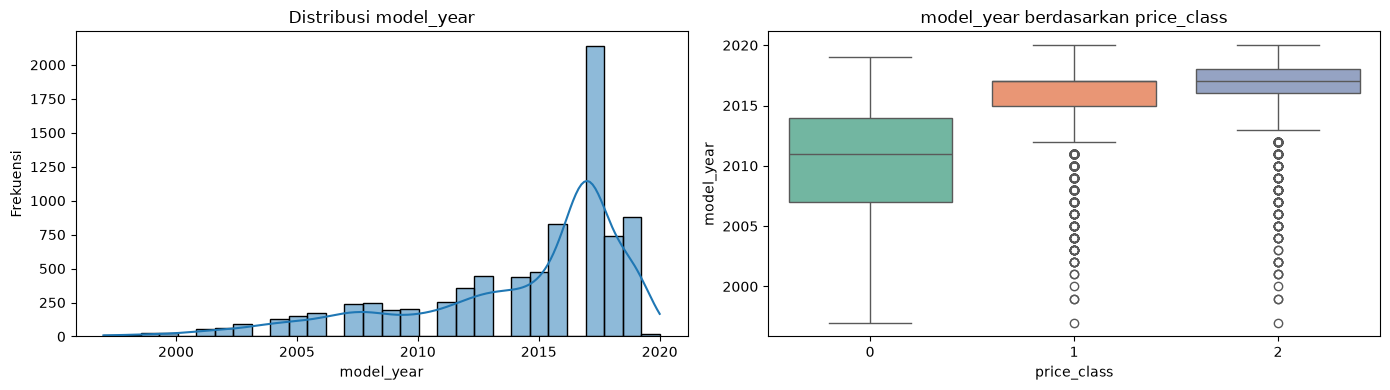

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


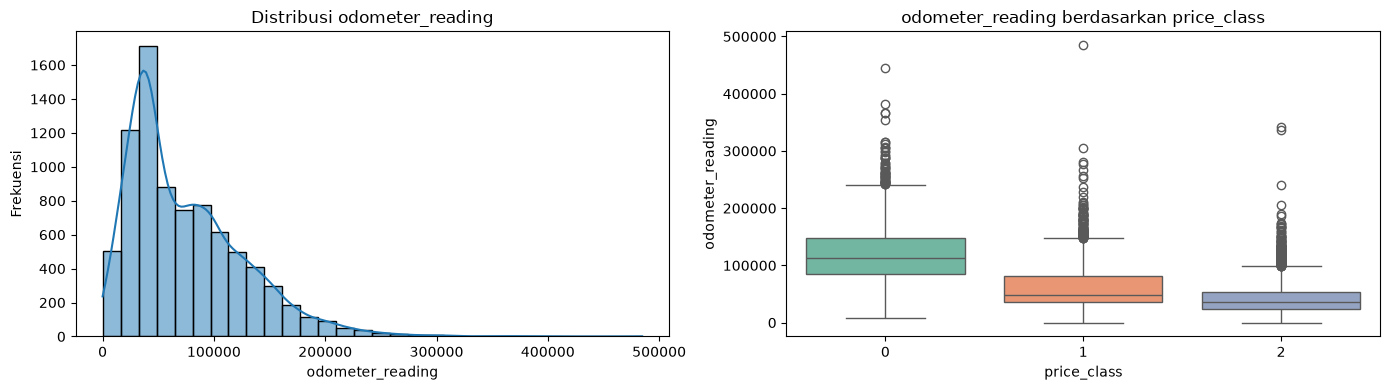

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


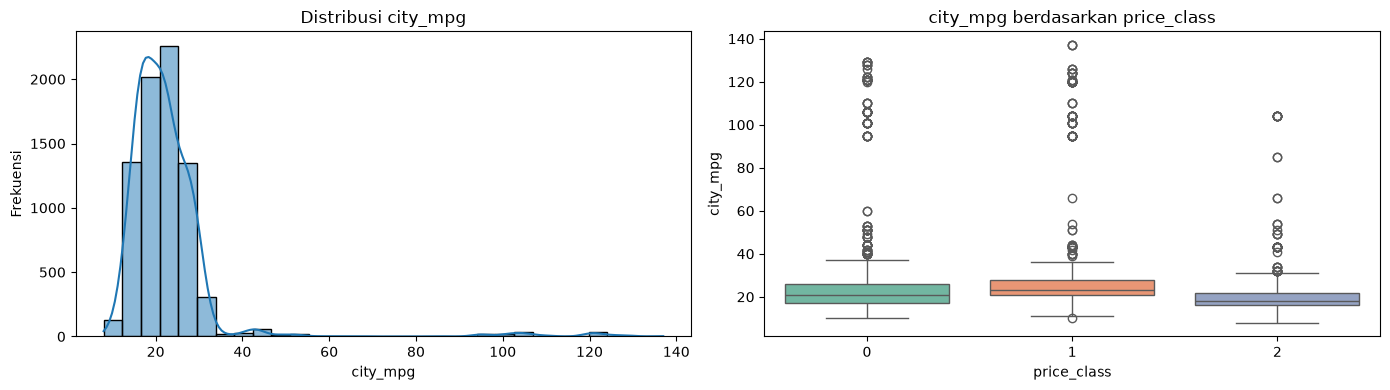

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


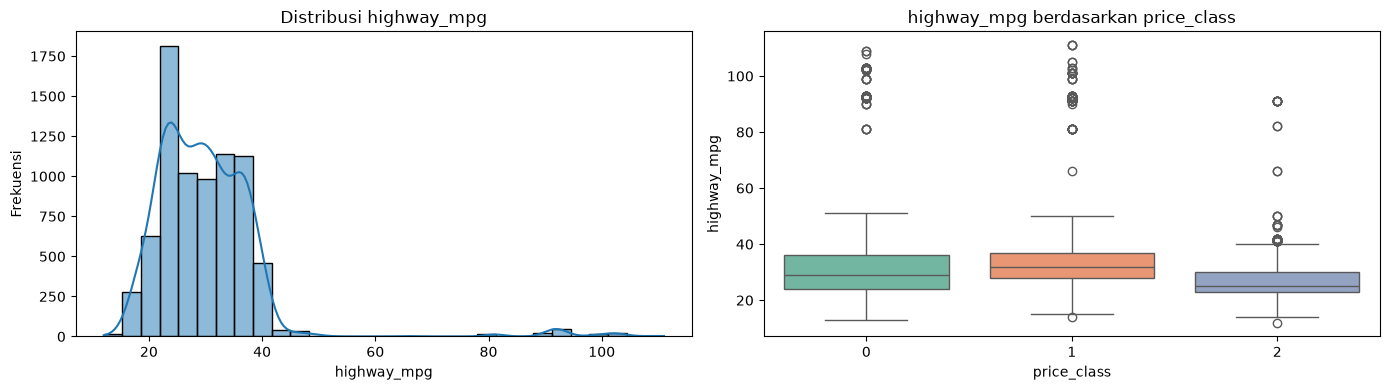

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


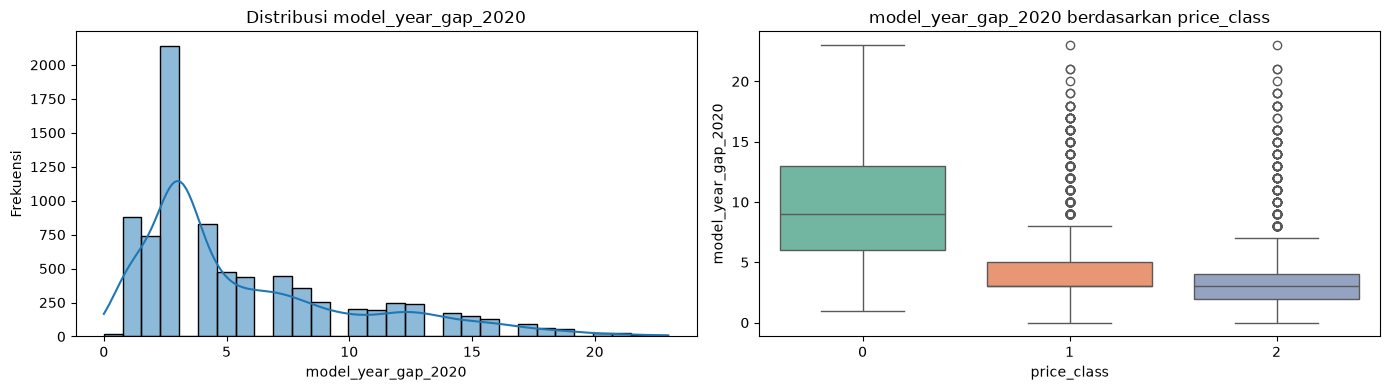

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


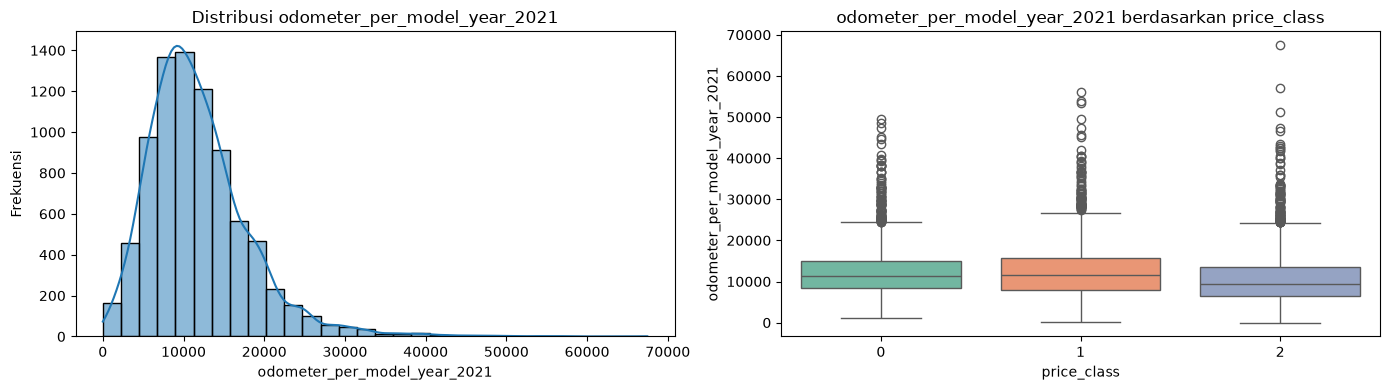

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


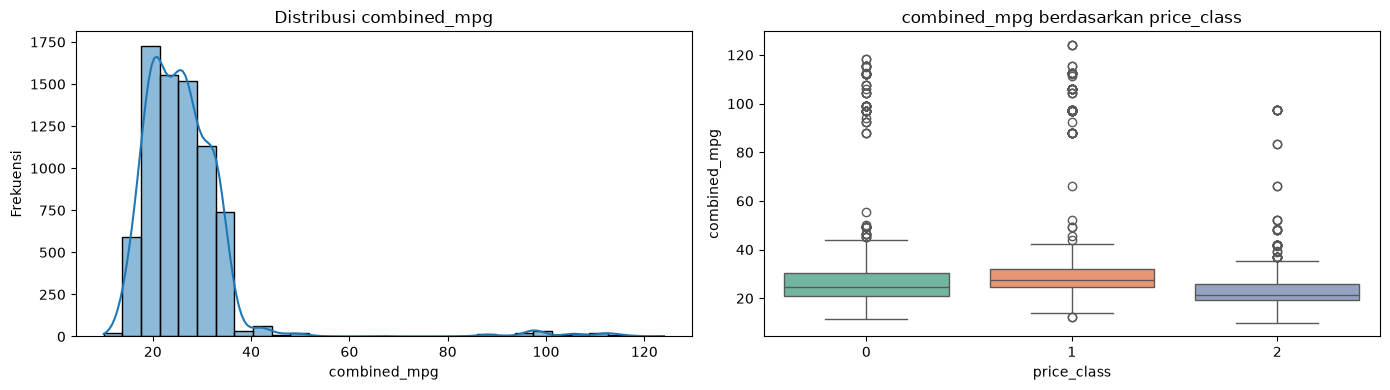

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


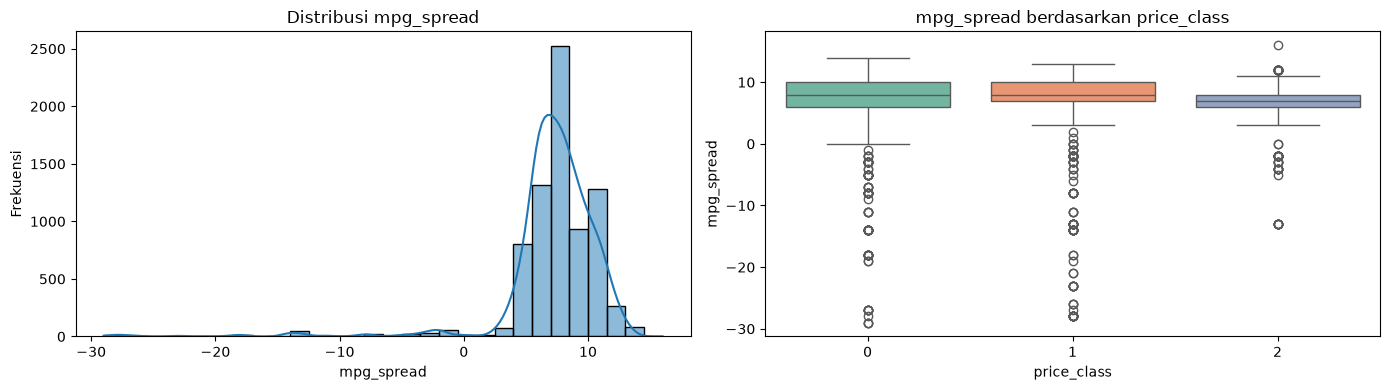

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


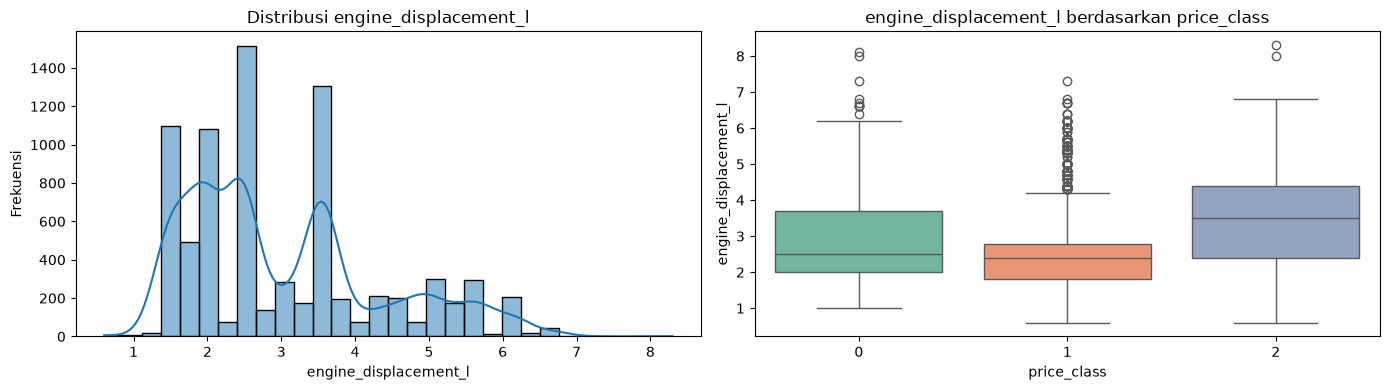

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


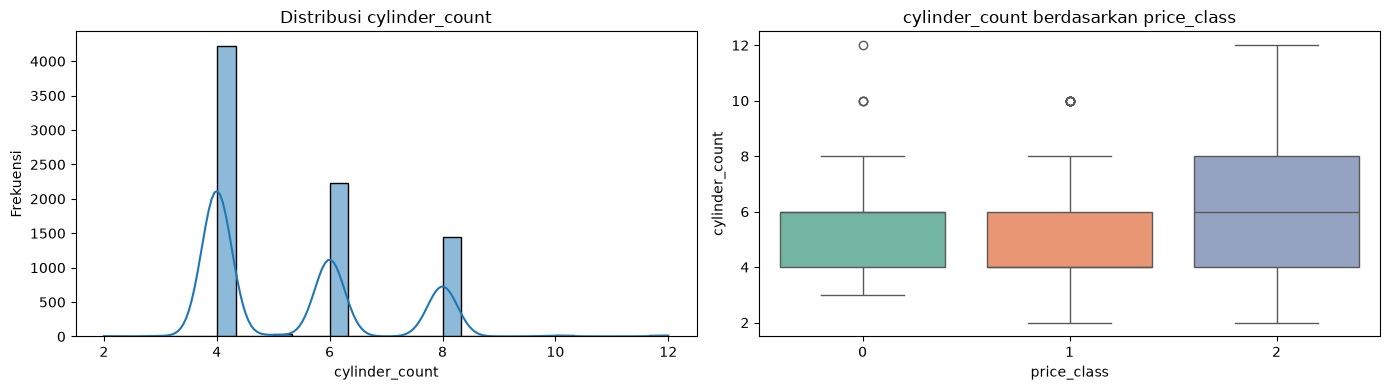

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


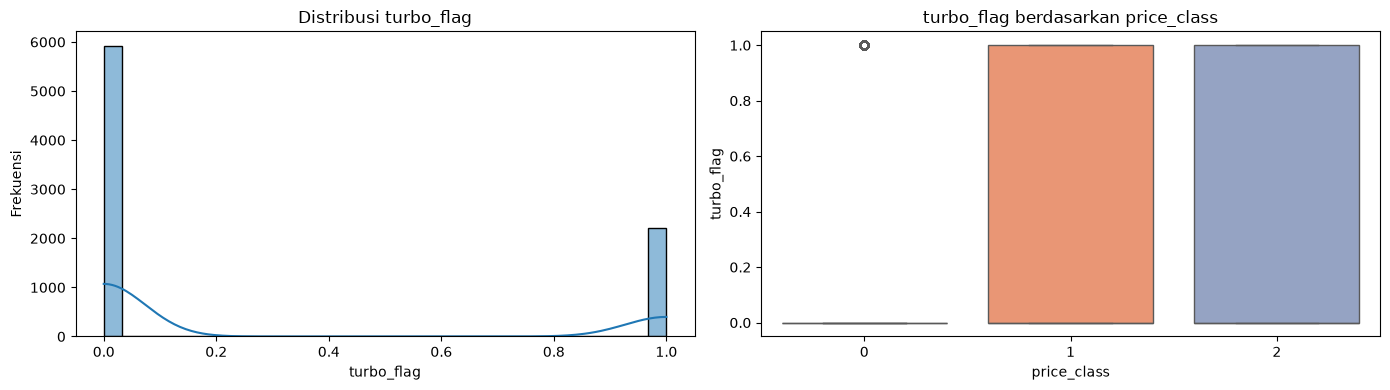

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


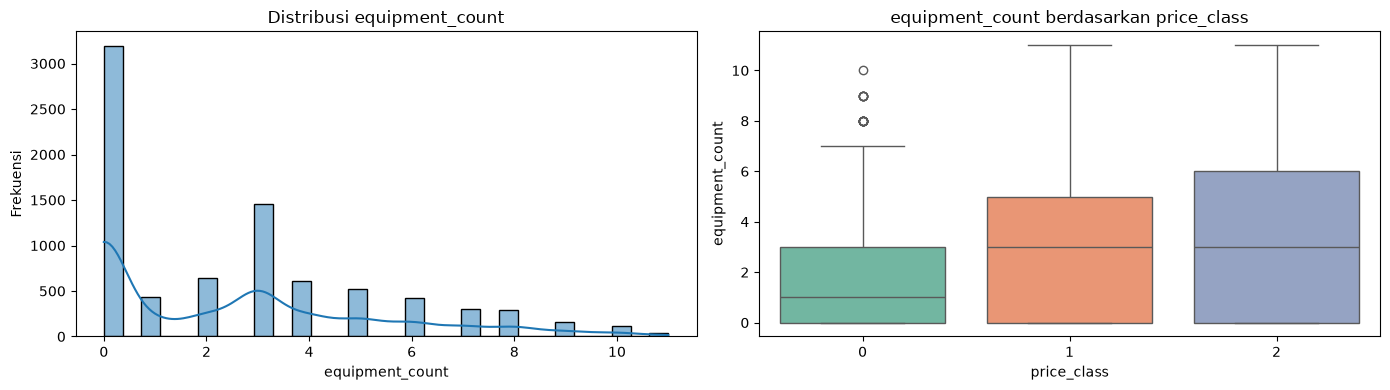

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


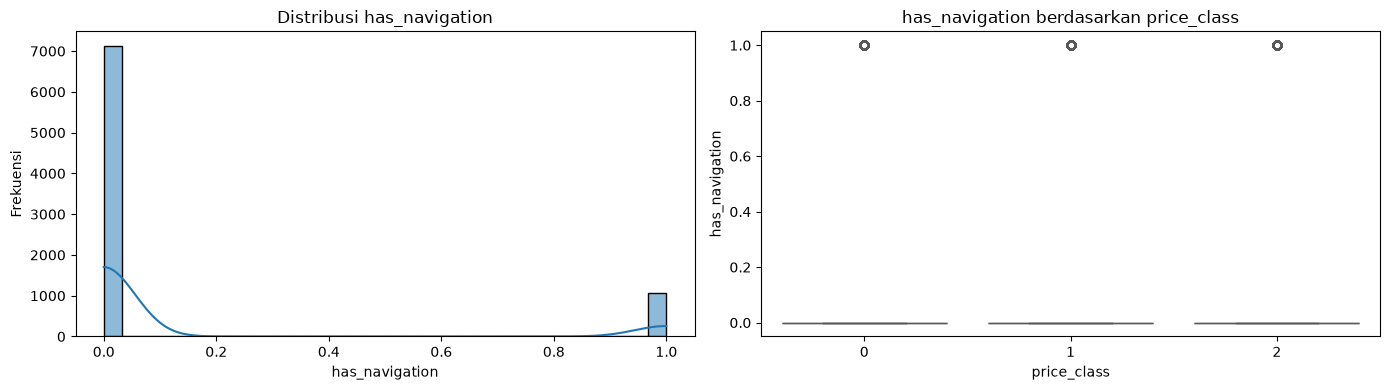

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


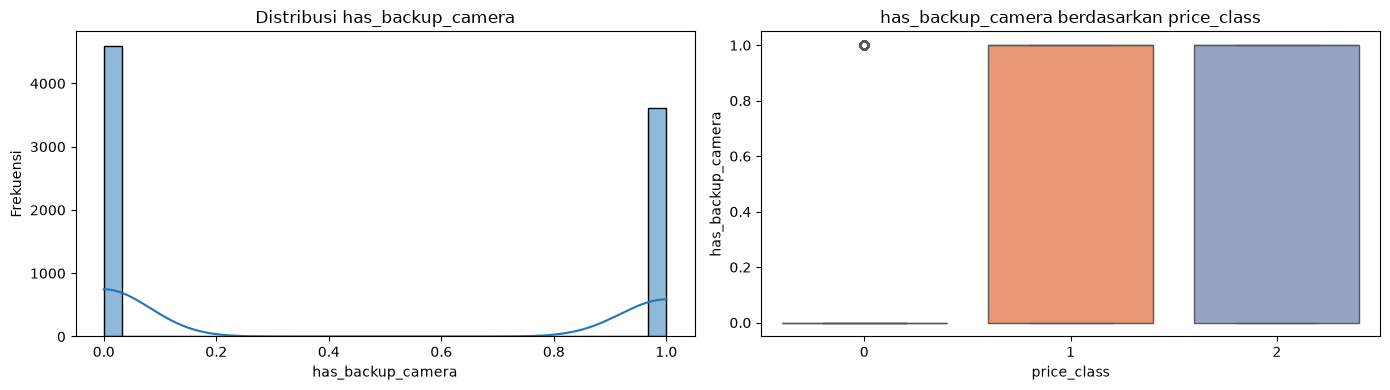

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


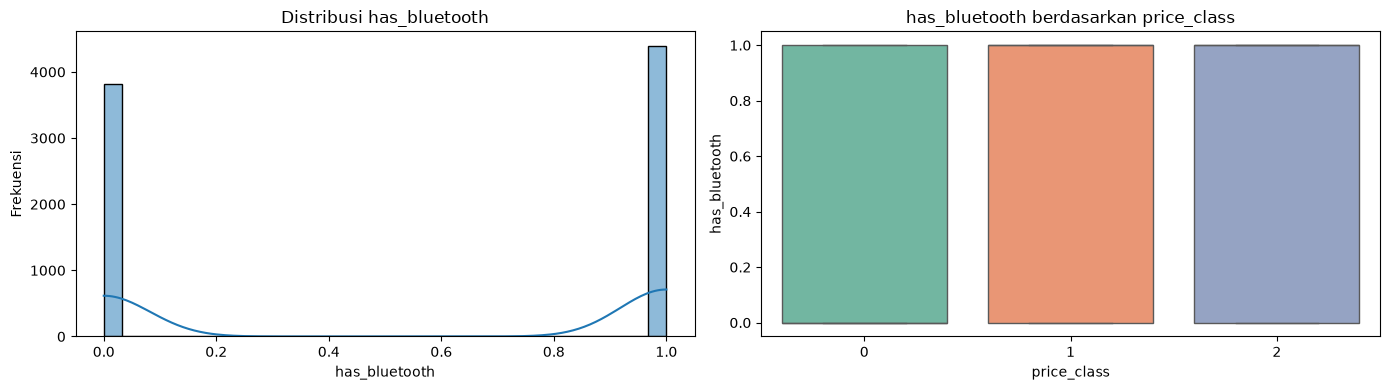

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


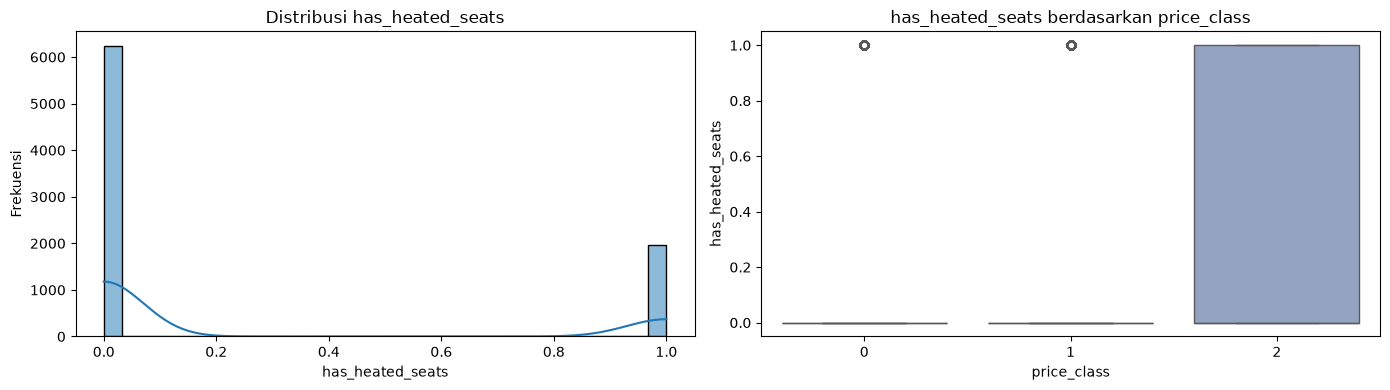

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


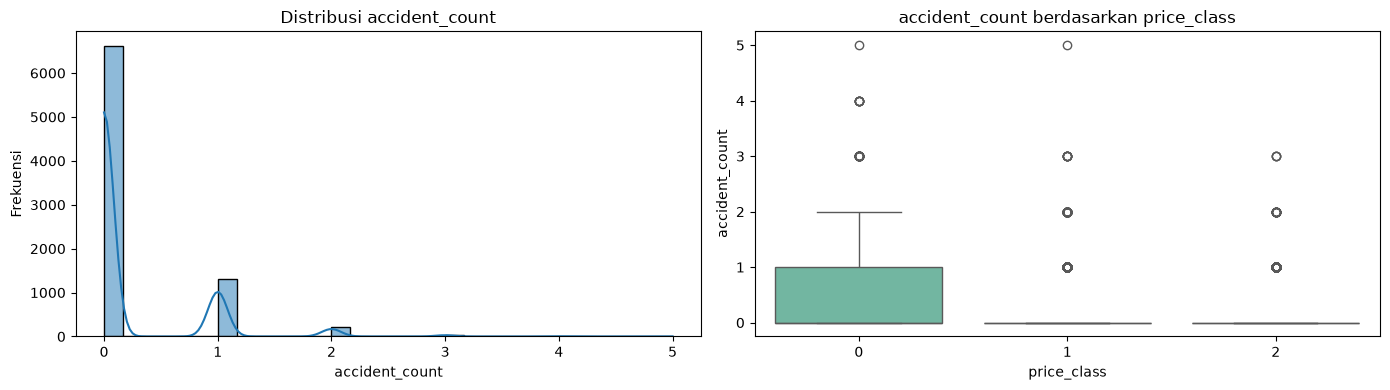

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


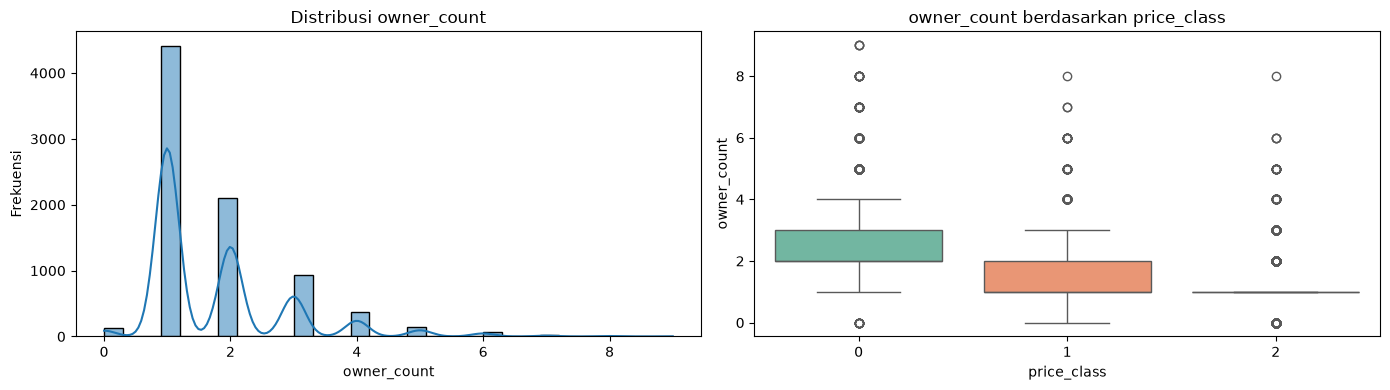

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


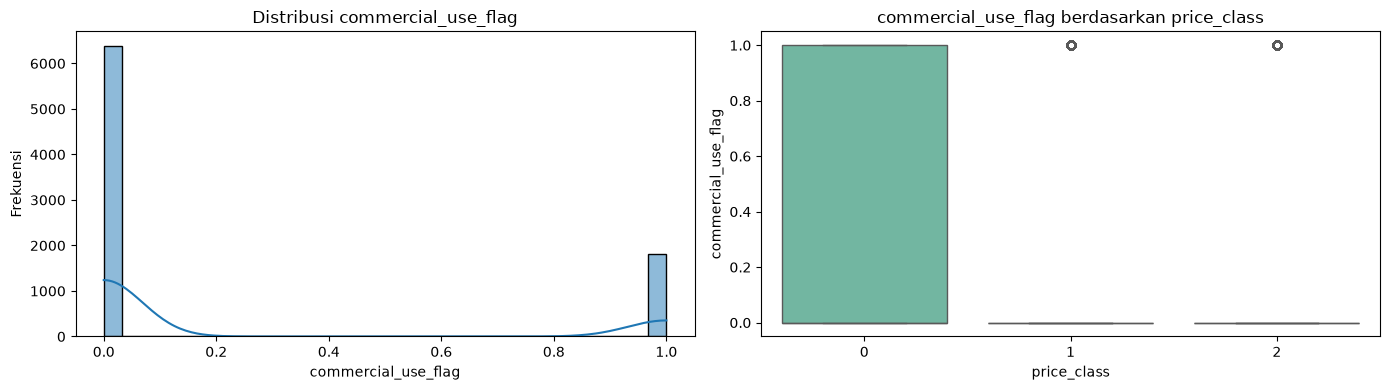

/tmp/ipykernel_35347/2132133468.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


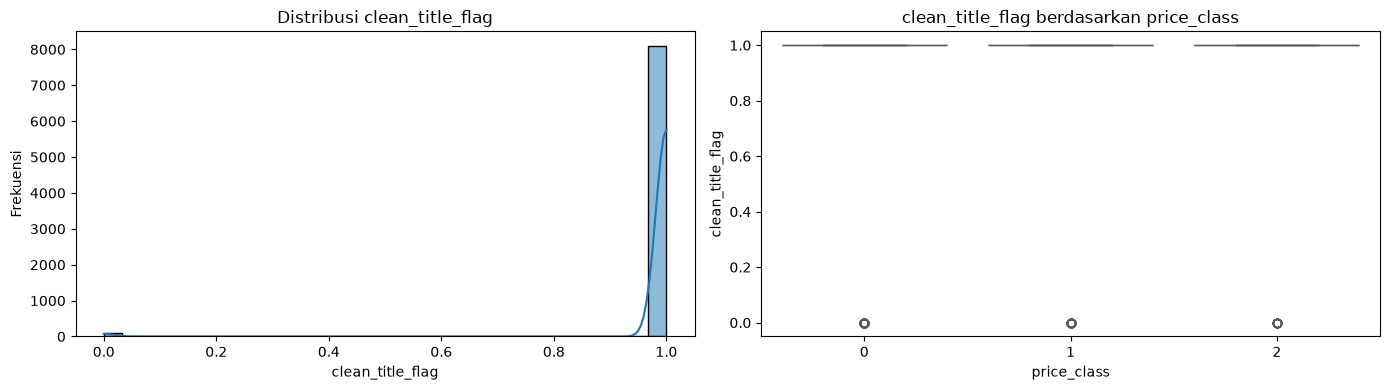

In [96]:
import seaborn as sns

# targett
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x=target_col)
plt.title(f"Distribusi {target_col}")
plt.xlabel(target_col)
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # histogram
    sns.histplot(
        data=df_train,
        x=col,
        bins=30,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribusi {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frekuensi")
    
    # boxplot per target
    sns.boxplot(
        data=df_train,
        x=target_col,
        y=col,
        palette="Set2",
        ax=axes[1]
    )
    axes[1].set_title(f"{col} berdasarkan {target_col}")
    axes[1].set_xlabel(target_col)
    axes[1].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

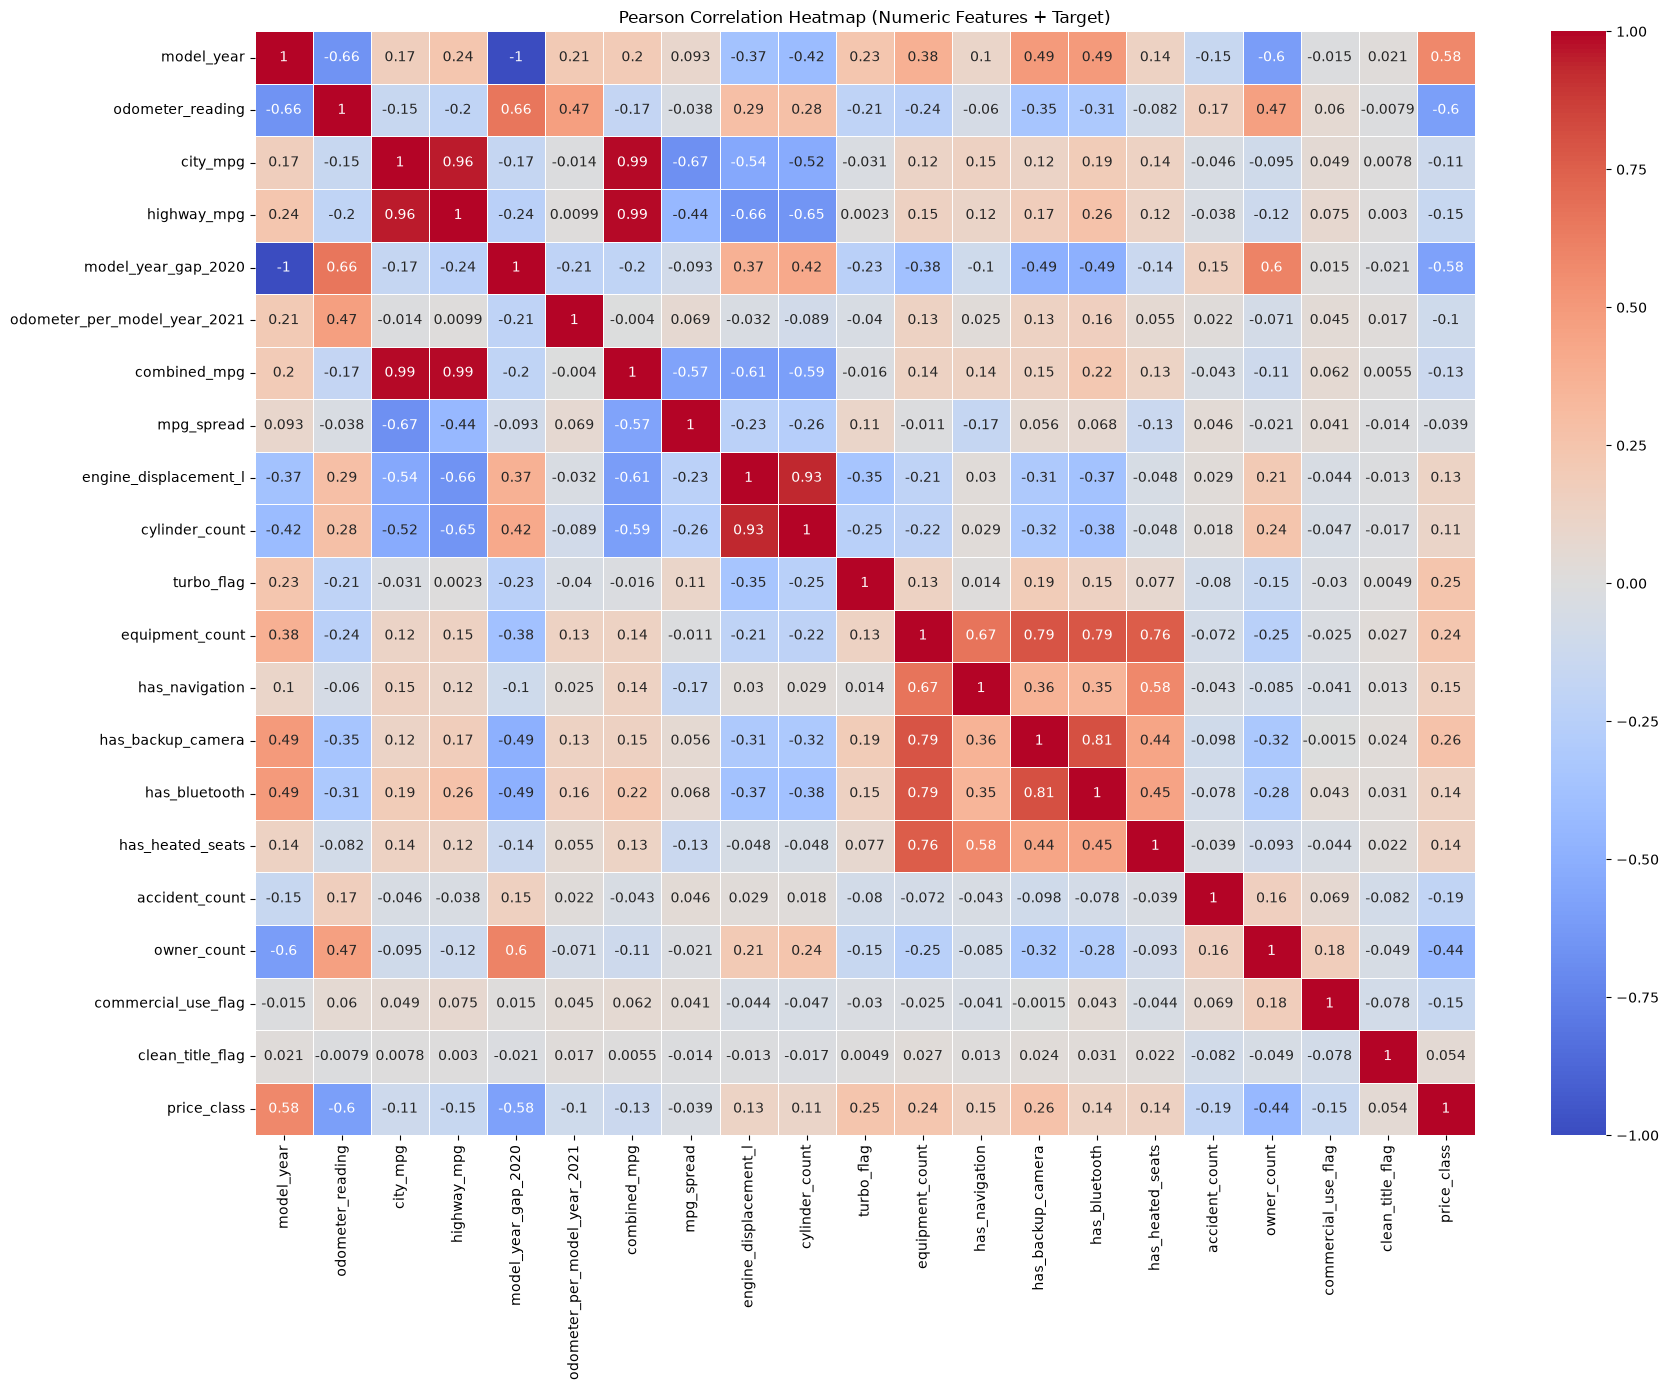

In [97]:
# Pearson
corr = df_train[numeric_cols + [target_col]].corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Pearson Correlation Heatmap (Numeric Features + Target)")
plt.tight_layout()
plt.show()

In [98]:
# Block EDA Missing Values (Perbaikan)
missing_summary = (
    df_train.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df_train) * 100
).round(2)
missing_summary["dtype"] = missing_summary["feature"].map(
    df_train.dtypes.astype(str)
)
missing_summary = missing_summary.sort_values(
    ["missing_count", "missing_pct"], ascending=False
).reset_index(drop=True)

display(missing_summary)

high_missing = missing_summary[missing_summary["missing_pct"] > 10].copy()
mid_missing = missing_summary[
    (missing_summary["missing_pct"] > 1) & (missing_summary["missing_pct"] <= 10)
].copy()
low_missing = missing_summary[
    (missing_summary["missing_pct"] <= 1) & (missing_summary["missing_count"] > 0)
].copy()

print("\nmissing > 10%:")
if high_missing.empty:
    print("gaada missing > 10%")
else:
    display(high_missing[["feature", "missing_count", "missing_pct", "dtype"]])

print("\nmissing 1% - 10%:")
if mid_missing.empty:
    print("gaada missing 1% - 10%")
else:
    display(mid_missing[["feature", "missing_count", "missing_pct", "dtype"]])

print("\nmissing <= 1%:")
if low_missing.empty:
    print("gaada missing <= 1% yang bernilai > 0")
else:
    display(low_missing[["feature", "missing_count", "missing_pct", "dtype"]])

,feature,missing_count,missing_pct,dtype
0,combined_mpg,658,8.02,float64
1,mpg_spread,658,8.02,float64
2,highway_mpg,533,6.50,float64
3,city_mpg,524,6.39,float64
4,body_color,225,2.74,str
5,cabin_color,205,2.50,str
6,cylinder_count,190,2.32,float64
7,engine_displacement_l,175,2.13,float64
8,trim,93,1.13,str
9,engine_spec,80,0.98,str



missing > 10%:
gaada missing > 10%

missing 1% - 10%:


,feature,missing_count,missing_pct,dtype
0,combined_mpg,658,8.02,float64
1,mpg_spread,658,8.02,float64
2,highway_mpg,533,6.50,float64
3,city_mpg,524,6.39,float64
4,body_color,225,2.74,str
5,cabin_color,205,2.50,str
6,cylinder_count,190,2.32,float64
7,engine_displacement_l,175,2.13,float64
8,trim,93,1.13,str



missing <= 1%:


,feature,missing_count,missing_pct,dtype
9,engine_spec,80,0.98,str
10,turbo_flag,80,0.98,float64


## Preprocessing

IDE-IDE habis EDA untuk preprocessing

NUMERIK:
Yang unik adalah targetnya sama rata, bener bener kayak 1/3 doanggg, berarti ini masalah sederhana banget

model_year korelasinya tinggi banget sama target

has_heated_seats dibuang
hsa_backup_camera dibuang
has_navigation dibuang
has_bluetooth dibuang
has_accident_count dibuang
clean_title_flag dibuang
model_year_gap_2020 dibuang gak sih? redundan sama model_year gak sih?
odometer_per_model_year_2021 dibuang atau dikeep? kok redundan sama odometer_reading?


city_mpg sama highway_mpg digabung aja gak sih? masukin combined_mpg gak sih

skewed parah:
mpg_spread
combined_mpg
model_year
odometer_reading
 

turbo_flag cuma target 1 sama 2 doang yang ada, yang target 0 bener bener jomplang. Ini sinyal atau bukan?
owner_count distribusi kelasnya aneh, banyak outlier, dan menurun banget. Sinyal atau bukan?
commercial_use_flag kok cuma kelas 0 doang yang dominan?

yang aneh tuh engin_displacement_I
cylinder_count diambil 4, 6, 8


CATEGORICAL:
body_color
cabin_color

energy source nya cuma Gas doang yang dominan, itu pun plotingannya sama rata (sama dengan distribusi aslinya sih), sisanya countsnya dikit banget


IDE PREPROCESSING:
missing value numerik diisi median
missing value kategorikal diisi modus
log-transform 
5 fold cross validation

In [99]:
from sklearn.model_selection import train_test_split

target_col = "price_class"
exclude_cols = ["id", target_col, "price"]

features = [c for c in df_train.columns if c not in exclude_cols]

numeric_cols = df_train[features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_train[features].select_dtypes(include=["object", "string"]).columns.tolist()

df_train[cat_cols] = df_train[cat_cols].astype(object)
df_test[cat_cols] = df_test[cat_cols].astype(object)

num_imputer = SimpleImputer(strategy="median")
df_train[numeric_cols] = num_imputer.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = num_imputer.transform(df_test[numeric_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_train[cat_cols] = cat_imputer.fit_transform(df_train[cat_cols])
df_test[cat_cols] = cat_imputer.transform(df_test[cat_cols])

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_train[cat_cols] = encoder.fit_transform(df_train[cat_cols].astype(str))
df_test[cat_cols] = encoder.transform(df_test[cat_cols].astype(str))

X = df_train[numeric_cols + cat_cols]
y = df_train[target_col]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = df_test[numeric_cols + cat_cols]

## Modeling 

**DILARANG MENGUBAH CODE!!!!!!!!!!!!**, sesuaikan semua varible yang dibutuhkan.

**Pastikan sudah memiliki variable berikut:**
`X_train, X_val, y_train, y_val -> df_train`

In [100]:
# Modeling using Decision Tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Precision: {precision_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"Recall: {recall_score(y_val, y_pred, average='macro', zero_division=0)}")
print(f"F1: {f1_score(y_val, y_pred, average='macro', zero_division=0)}")
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy: 0.7666057282145033
Precision: 0.7669064526631644
Recall: 0.7678354355177772
F1: 0.7672461844063027
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       521
           1       0.67      0.66      0.67       560
           2       0.84      0.82      0.83       560

    accuracy                           0.77      1641
   macro avg       0.77      0.77      0.77      1641
weighted avg       0.77      0.77      0.77      1641



# Submission

**DILARANG MENGUBAH CODE!!!!!!!!!!!**

**Pastikan memiliki variable berikut:**
`X_test -> df_test`

In [101]:
id = df_test['id'].tolist()

y_test = model.predict(X_test)
submission_df = pd.DataFrame({'id': id, 'price': y_test})
submission_df.to_csv('submission.csv', index=False)